# Genre Trend Analysis

How movie genres evolved over time and whether studios produced content aligned with audience demand.

We examine:

- Production volume per genre

- Audience popularity trends

- Market supply vs demand imbalance

- Genre growth and decline

- Profitability and success probability



## 1. Data Preparation Section

### Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load cleaned csv

In [2]:
movies = pd.read_csv("movies_cleaned.csv")
movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,director_count,main_director,has_director,good_director_data,missing_writers,has_multiple_writers,writers_count,main_writer,has_writers,good_writers_data
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
2,5,Four Rooms,5.9,2780,Released,1995-12-09,4257354,98,4000000,tt0113101,...,4,Alexandre Rockwell,True,True,False,True,4,Allison Anders,True,True
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,1,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True
4,9,Sunday in August,6.8,28,Released,2004-09-02,0,15,0,tt0425473,...,1,Marc Meyer,True,True,False,False,1,Marc Meyer,True,True


### Prepare Date + Decade

In [7]:
# convert release_date to datetime
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# extract year
movies['year'] = movies['release_date'].dt.year

# create decade column (1995 → 1990s)
movies['decade'] = (movies['year'] // 10) * 10

movies[['release_date','year','decade']].head()

,release_date,year,decade
0,1988-10-21,1988,1980
1,1986-10-17,1986,1980
2,1995-12-09,1995,1990
3,1993-10-15,1993,1990
4,2004-09-02,2004,2000


### Clean and Split Genres

In [10]:
# split into list
movies['genres_list'] = movies['genres'].str.split(',')

# strip spaces
movies['genres_list'] = movies['genres_list'].apply(
    lambda x: [g.strip() for g in x] if isinstance(x, list) else []
)

# remove duplicates inside each movie
movies['genres_list'] = movies['genres_list'].apply(lambda x: list(set(x)))

movies[['genres', 'genres_list']].head(10)


,genres,genres_list
0,"Comedy, Drama, Romance, Crime","[Comedy, Drama, Crime, Romance]"
1,"Comedy, Drama, Romance","[Comedy, Drama, Romance]"
2,Comedy,[Comedy]
3,"Action, Crime, Thriller","[Thriller, Crime, Action]"
4,Drama,[Drama]
5,"Adventure, Action, Science Fiction","[Science Fiction, Adventure, Action]"
6,"Animation, Family","[Family, Animation]"
7,"Comedy, Drama, Romance","[Comedy, Drama, Romance]"
8,Drama,[Drama]
9,"Mystery, Drama","[Drama, Mystery]"


### Explode

In [9]:
movies_genre = movies.explode('genres_list')

movies_genre = movies_genre.rename(columns={'genres_list':'genre'})

movies_genre.head(10)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,main_director,has_director,good_director_data,missing_writers,has_multiple_writers,writers_count,main_writer,has_writers,good_writers_data,year
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1988
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1988
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1988
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1988
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1986
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1986
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True,1986
2,5,Four Rooms,5.9,2780,Released,1995-12-09,4257354,98,4000000,tt0113101,...,Alexandre Rockwell,True,True,False,True,4,Allison Anders,True,True,1995
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True,1993
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True,1993


## Frequency by Decade

In [11]:
genre_counts = (
    movies_genre
    .groupby(['decade','genre'])
    .size()
    .reset_index(name='movie_count')
)

genre_counts.head()


,decade,genre,movie_count
0,1880,Documentary,2
1,1890,Action,6
2,1890,Animation,3
3,1890,Comedy,49
4,1890,Crime,2


### Pivot for Visualisation

In [12]:
genre_counts_pivot = genre_counts.pivot(index='decade', columns='genre', values='movie_count').fillna(0)

genre_counts_pivot.tail()


genre,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
decade,,,,,,,,,,,,,,,,,,,
2000,6310.0,2684.0,3572.0,17688.0,4342.0,14417.0,27734.0,3796.0,2596.0,1855.0,6971.0,5273.0,2337.0,7539.0,2442.0,4367.0,6443.0,943.0,272.0
2010,10031.0,4942.0,6298.0,33593.0,7207.0,29243.0,59018.0,6419.0,5882.0,4114.0,16173.0,7820.0,5518.0,13918.0,6143.0,5485.0,14019.0,1817.0,602.0
2020,9063.0,4787.0,6687.0,36025.0,8152.0,31282.0,66704.0,6166.0,7754.0,3836.0,21298.0,9201.0,8001.0,13245.0,7317.0,4494.0,19278.0,1470.0,916.0
2030,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2060,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


##  2. Production Trends(Heatmap)
### Average TMDB popularity per genre-decade

In [13]:
genre_popularity = (
    movies_genre
    .groupby(['decade','genre'])['popularity']
    .mean()
    .reset_index(name='avg_popularity')
)

genre_popularity.head()


,decade,genre,avg_popularity
0,1880,Documentary,0.747600
1,1890,Action,1.921817
2,1890,Animation,0.889633
3,1890,Comedy,0.918353
4,1890,Crime,1.742500


### Combine Volume + Interest

In [14]:
genre_trends = pd.merge(genre_counts, genre_popularity, on=['decade','genre'])

genre_trends.head()


,decade,genre,movie_count,avg_popularity
0,1880,Documentary,2,0.747600
1,1890,Action,6,1.921817
2,1890,Animation,3,0.889633
3,1890,Comedy,49,0.918353
4,1890,Crime,2,1.742500


### Visualise Trends

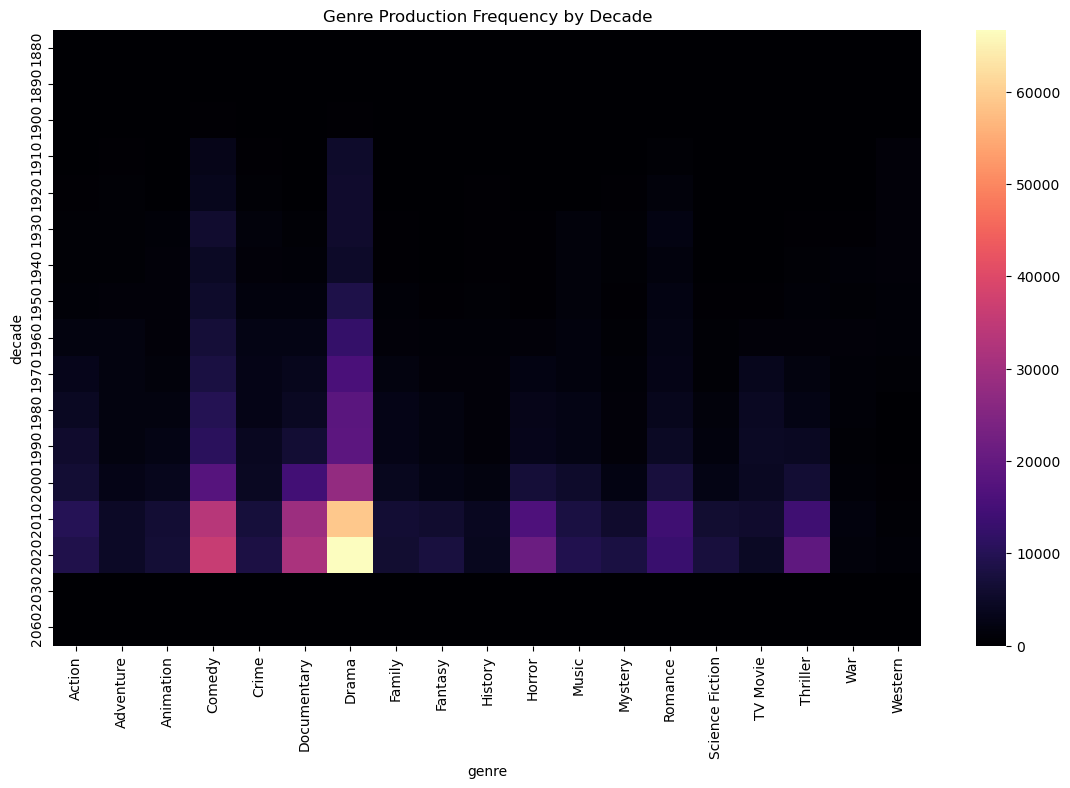

In [26]:
plt.figure(figsize=(14,8))
sns.heatmap(genre_counts_pivot, cmap='magma')
plt.title("Genre Production Frequency by Decade")
plt.show()


## 3. Audience Interest(Popularity Heatmap)

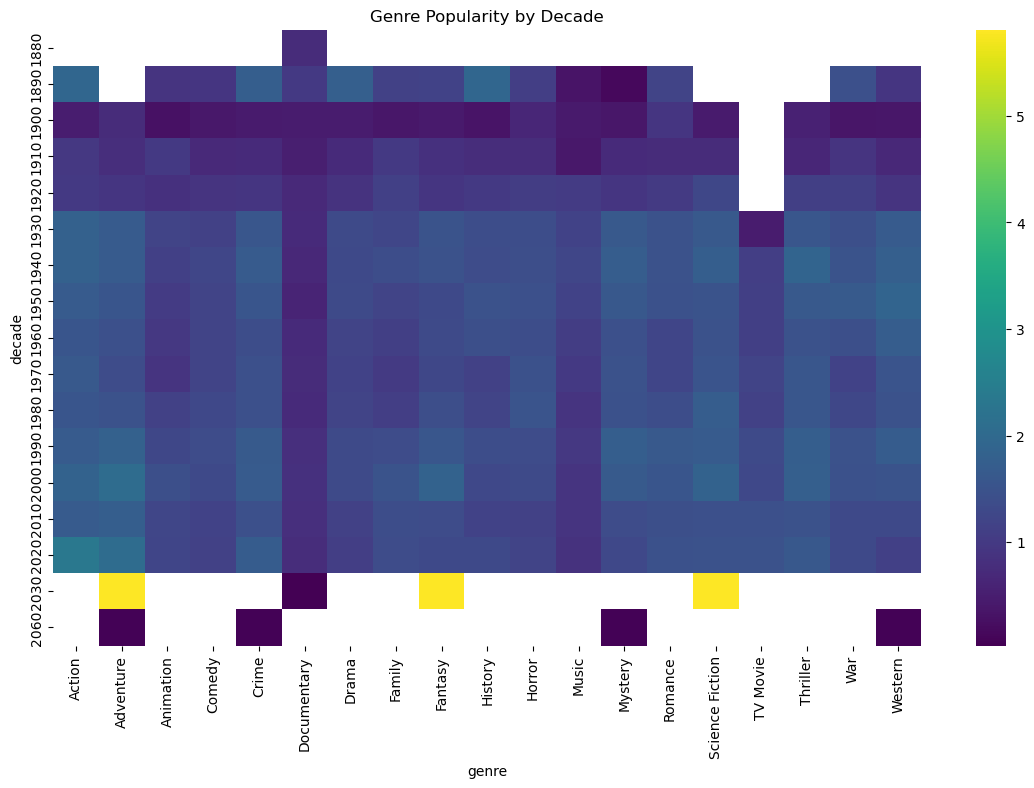

In [18]:
popularity_pivot = genre_popularity.pivot(index='decade', columns='genre', values='avg_popularity')

plt.figure(figsize=(14,8))
sns.heatmap(popularity_pivot, cmap='viridis')
plt.title("Genre Popularity by Decade")
plt.show()


## 4. Demand Supply Gap
#### If popularity is high but movie_count low → audience wants more
#### If movie_count high but popularity low → studios oversaturated market

In [19]:
# normalize both metrics
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

genre_trends[['count_norm','pop_norm']] = scaler.fit_transform(
    genre_trends[['movie_count','avg_popularity']]
)

# demand gap
genre_trends['demand_gap'] = genre_trends['pop_norm'] - genre_trends['count_norm']

genre_trends.head()


,decade,genre,movie_count,avg_popularity,count_norm,pop_norm,demand_gap
0,1880,Documentary,2,0.747600,0.000015,0.124354,0.124339
1,1890,Action,6,1.921817,0.000075,0.327439,0.327364
2,1890,Animation,3,0.889633,0.000030,0.148919,0.148889
3,1890,Comedy,49,0.918353,0.000720,0.153886,0.153166
4,1890,Crime,2,1.742500,0.000015,0.296425,0.296410


### Visualise most over/under supplied genres

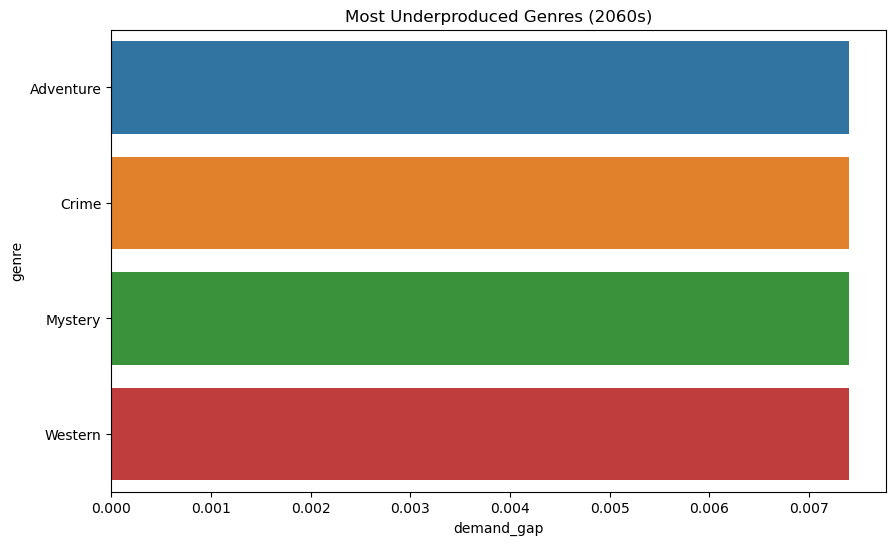

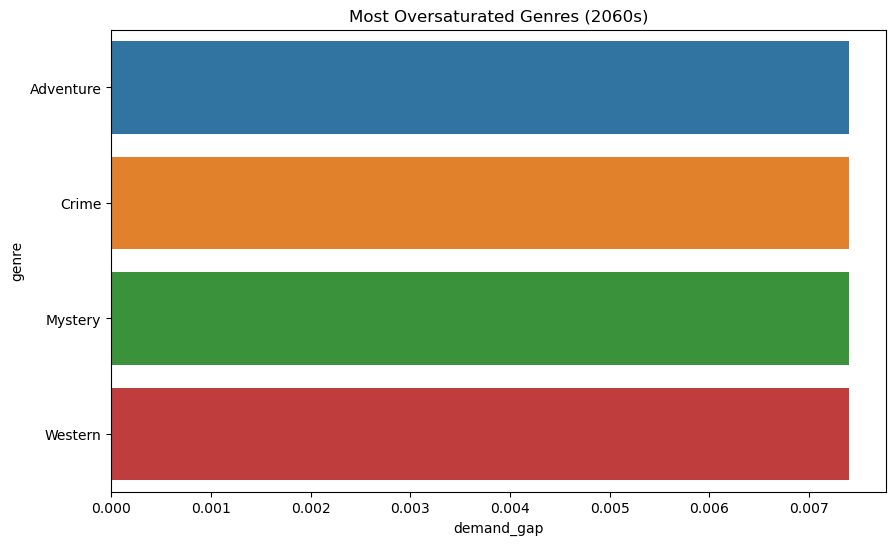

In [20]:
latest_decade = genre_trends['decade'].max()

gap_latest = genre_trends[genre_trends['decade'] == latest_decade]\
                .sort_values('demand_gap')

plt.figure(figsize=(10,6))
sns.barplot(data=gap_latest.tail(10), x='demand_gap', y='genre')
plt.title(f"Most Underproduced Genres ({latest_decade}s)")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=gap_latest.head(10), x='demand_gap', y='genre')
plt.title(f"Most Oversaturated Genres ({latest_decade}s)")
plt.show()


## 5. Rising vs Decling Genres
### Computer Popularity Growth

In [21]:
genre_popularity_sorted = genre_popularity.sort_values(['genre','decade'])

genre_popularity_sorted['pop_change'] = (
    genre_popularity_sorted
    .groupby('genre')['avg_popularity']
    .diff()
)

genre_popularity_sorted.head(20)


,decade,genre,avg_popularity,pop_change
1,1890,Action,1.921817,NaN
16,1900,Action,0.495074,-1.426743
34,1910,Action,0.971315,0.476241
52,1920,Action,0.986048,0.014732
70,1930,Action,1.793765,0.807717
89,1940,Action,1.806933,0.013168
108,1950,Action,1.666360,-0.140573
127,1960,Action,1.563832,-0.102528
146,1970,Action,1.621335,0.057503
165,1980,Action,1.542806,-0.078529


### Find Trending Genres

In [22]:
trend_score = (
    genre_popularity_sorted.groupby('genre')['pop_change']
    .mean()
    .reset_index()
    .sort_values('pop_change', ascending=False)
)

trend_score.head(10)   # rising genres
trend_score.tail(10)   # declining genres


,genre,pop_change
7,Family,0.014756
10,Horror,0.007618
12,Mystery,-0.005296
17,War,-0.010346
9,History,-0.047568
5,Documentary,-0.047933
1,Adventure,-0.048412
6,Drama,-0.050986
18,Western,-0.060119
4,Crime,-0.119364


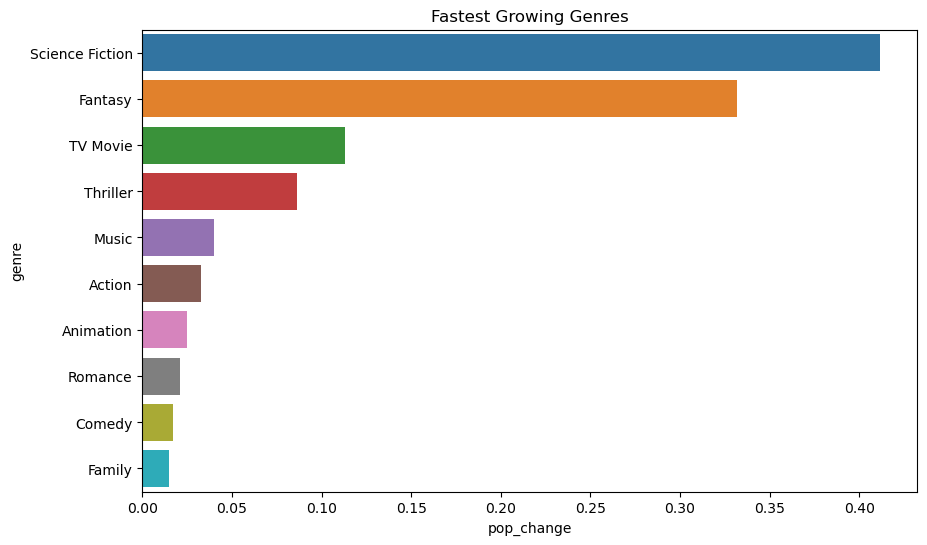

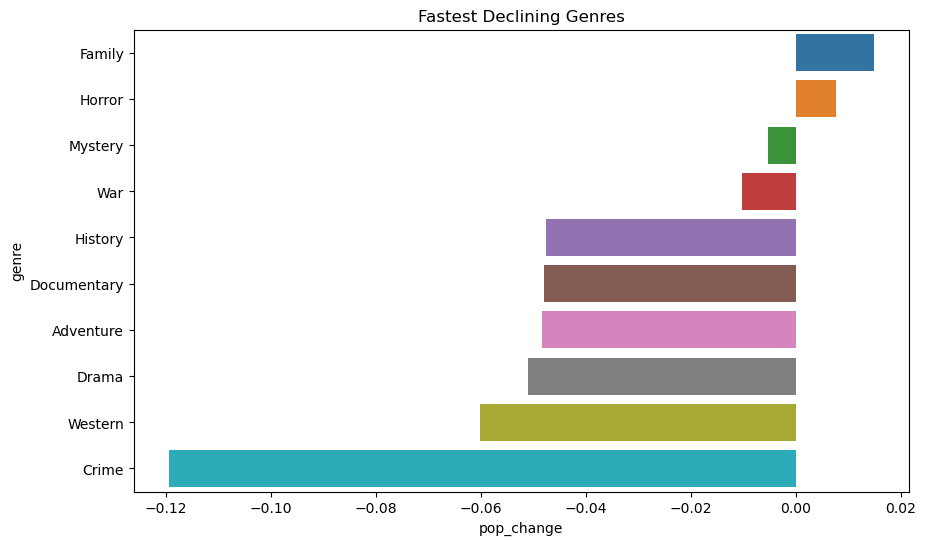

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=trend_score.head(10), x='pop_change', y='genre')
plt.title("Fastest Growing Genres")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=trend_score.tail(10), x='pop_change', y='genre')
plt.title("Fastest Declining Genres")
plt.show()


## 6. Genre Stability
#### High volatility = fad genre
#### Low volatility = stable genre

In [23]:
genre_variability = (
    genre_popularity.groupby('genre')['avg_popularity']
    .std()
    .reset_index(name='popularity_volatility')
    .sort_values('popularity_volatility', ascending=False)
)

genre_variability.head(10)


,genre,popularity_volatility
1,Adventure,1.264769
14,Science Fiction,1.234025
8,Fantasy,1.220124
12,Mystery,0.577299
18,Western,0.545738
4,Crime,0.510259
0,Action,0.462240
16,Thriller,0.407897
9,History,0.363911
17,War,0.327485


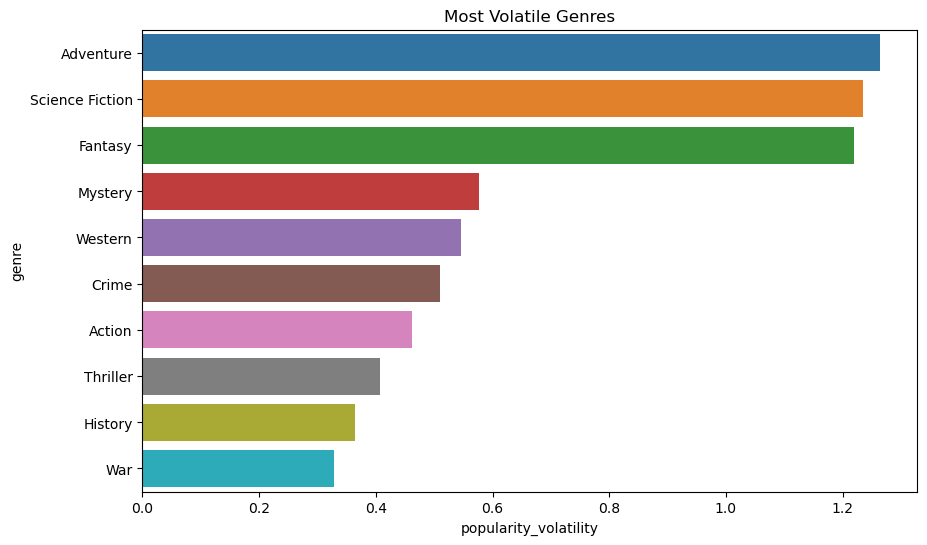

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=genre_variability.head(10), x='popularity_volatility', y='genre')
plt.title("Most Volatile Genres")
plt.show()


## 7. Genre Profitability 
### ROI by Genre

In [24]:
movies['roi'] = (movies['revenue'] - movies['budget']) / movies['budget']
movies['roi'] = movies['roi'].replace([np.inf, -np.inf], np.nan)

movies_genre = movies.explode('genres_list').rename(columns={'genres_list':'genre'})

genre_roi = (
    movies_genre.groupby('genre')['roi']
    .median()
    .reset_index()
    .sort_values('roi', ascending=False)
)

genre_roi.head(10)


,genre,roi
1,Adventure,-0.917083
0,Action,-1.000000
10,Horror,-1.000000
17,War,-1.000000
16,Thriller,-1.000000
15,TV Movie,-1.000000
14,Science Fiction,-1.000000
13,Romance,-1.000000
12,Mystery,-1.000000
11,Music,-1.000000


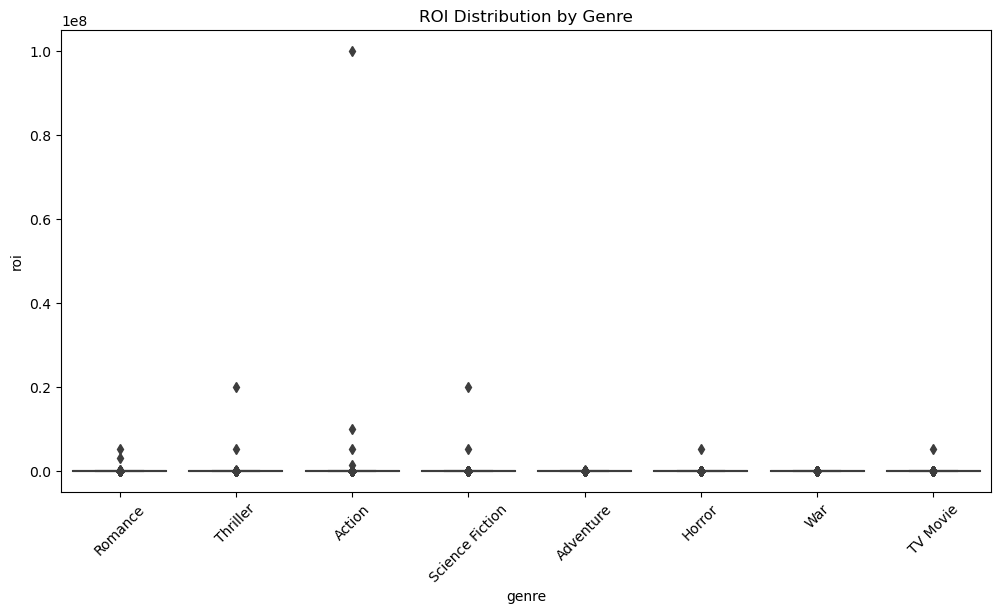

In [29]:
top_genres = genre_roi.head(8)['genre']

plt.figure(figsize=(12,6))
sns.boxplot(data=movies_genre[movies_genre['genre'].isin(top_genres)],
            x='genre', y='roi')
plt.xticks(rotation=45)
plt.title("ROI Distribution by Genre")
plt.show()


## 8. Success Probability by Genre

In [25]:
hit_threshold = movies['popularity'].quantile(0.75)
movies['is_hit'] = movies['popularity'] >= hit_threshold

movies_genre = movies.explode('genres_list').rename(columns={'genres_list':'genre'})

genre_hit_rate = (
    movies_genre.groupby('genre')['is_hit']
    .mean()
    .reset_index(name='hit_probability')
    .sort_values('hit_probability', ascending=False)
)

genre_hit_rate.head(10)


,genre,hit_probability
0,Action,0.412046
1,Adventure,0.375132
4,Crime,0.365809
16,Thriller,0.364547
18,Western,0.358836
13,Romance,0.353388
15,TV Movie,0.336649
17,War,0.335974
12,Mystery,0.331142
14,Science Fiction,0.327264


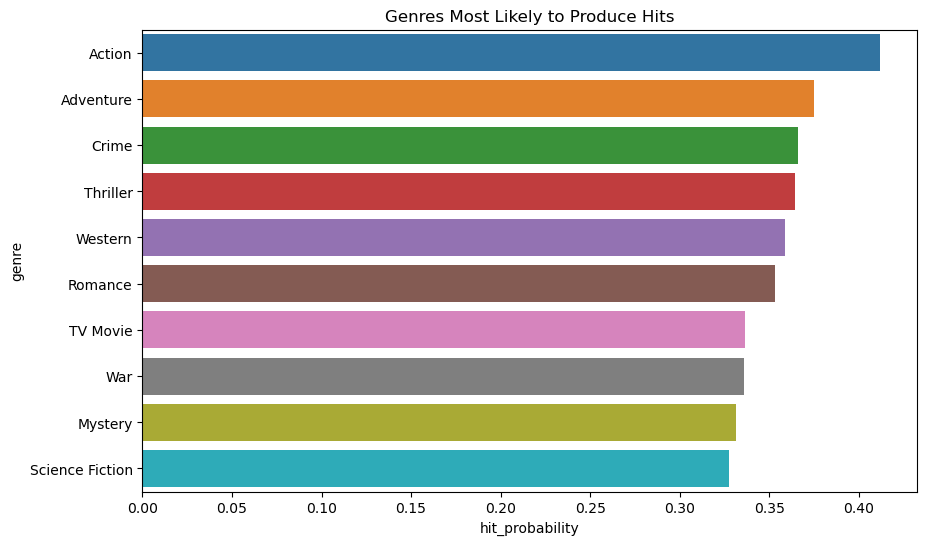

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(data=genre_hit_rate.head(10), x='hit_probability', y='genre')
plt.title("Genres Most Likely to Produce Hits")
plt.show()


## Conclusion